In [9]:
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
import random
from itertools import combinations, chain
import functools
from typing import Callable
import math
from tqdm import tqdm

In [10]:
# Basic parameters for the experiment
SHARE_NUMBER = N = 10
MINIMUM_SHARE = K = 3
BITLENGTH = M = 8
ALPHA = ...
R = (..., ...) # sould be symmetrical in case of experiment, but we also have asymmetrical cases (ref paper).

In [11]:
# Preparing types for data

# a 1D array of bits with shape size of M
Share = npt.NDArray[np.bool_] 
# a 2D array of bits with shape size of N x M
C_Matrix = npt.NDArray[np.bool_]

In [12]:
def display(share: Share | C_Matrix, fmt: tuple[int, int] = (1, -1), Label: str = "", grid=False) -> None:
    """Display a single share as an image."""
    fig, ax = plt.subplots()
    # check if the share can be reshaped to the specified format
    if share.size != np.prod(fmt) and fmt != (1, -1):
        raise ValueError(f"Cannot reshape share of size {share.size} to format {fmt}.")
    
    # quick way to reshape the share if it's 1D, otherwise keep it as is
    match share.ndim:
        case 1: 
            share_reshaped = share.reshape(fmt)  
        case 2: 
            share_reshaped = share
        case _: 
            raise ValueError(f"Unsupported share dimensions: {share.ndim})")
    assert share_reshaped.ndim == 2, "Share must be 2D after reshaping."

    h, w = share_reshaped.shape
    ax.imshow(
        share_reshaped,
        cmap="gray_r",
        vmin=0,
        vmax=1
    )

    # Explicit separators on top of the image to avoid backend/style grid quirks
    if grid:
        for x in range(w + 1):
            ax.axvline(x - 0.5, color="lightgray", linewidth=1)
        for y in range(h + 1):
            ax.axhline(y - 0.5, color="lightgray", linewidth=1)

    ax.set_xlim(-0.5, w - 0.5)
    ax.set_ylim(h - 0.5, -0.5)
    ax.set_title(Label)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    plt.show()

In [13]:
def shuffle(matrix: C_Matrix)-> None:
    """Shuffle the column of a matrix."""
    np.random.shuffle(matrix.T)
    matrix.T


def random_sampling_shares(C_0: C_Matrix, C_1: C_Matrix, secret_pixel: bool|None=None) ->tuple[bool, list[Share]]:
    """
    TODO validate that this process is as described in the paper.
    Emulate a Random share creation based on the two matrix C_0 and C_1.
    based on a secrete pixel 
    
    output 
    - list share: the generated share as a 1D array of bits (size M) 
    """
    
    if C_0.shape != C_1.shape:
        raise ValueError(f"C_0 and C_1 must have the same shape, got {C_0.shape} and {C_1.shape}.")
    N, _ = C_0.shape
    
    secret_pixel_value = secret_pixel if secret_pixel is not None else np.random.choice([False, True])
    C = C_1 if secret_pixel_value else C_0
    
    shares = []
    for i in range(N):
        share = C[i]
        shares.append(share)
    return secret_pixel_value, shares
    

Test matrix of shares:
[False  True False False  True  True False  True]


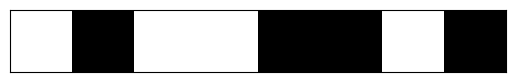

Test matrix 2 of shares:
[False  True  True False  True  True False  True]


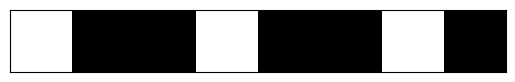

Result of share addition:
[False  True  True False  True  True False  True]


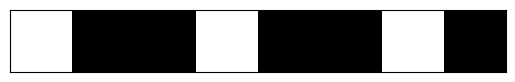

In [14]:
def share_add(a_share: Share, b_share: Share) -> Share:
    assert a_share.shape == b_share.shape, "Shares must have the same shape for addition."
    return np.logical_or(a_share, b_share)

def matrix_share_add(matrix_share: C_Matrix) -> Share:
    assert matrix_share.ndim == 2, "Input must be a 2D matrix of shares."
    return np.logical_or.reduce(matrix_share, axis=0)

SHARE_SIZE = (BITLENGTH,)
test_matrix = np.random.randint(0, 2, size=SHARE_SIZE).astype(bool)
test_m2 = np.random.randint(0, 2, size=SHARE_SIZE).astype(bool)
print("Test matrix of shares:")
print(test_matrix)
display(test_matrix)
print("Test matrix 2 of shares:")
print(test_m2)
display(test_m2)
result = share_add(test_matrix, test_m2)
print("Result of share addition:")
print(result)
display(result)

# First impl, 3 out of 3 shares
- size of shares: 4 bits
- number of shares: 3
- C=(3, 4)

Thus:

- $C_{0}$ is a column of 0s concatenated with negated identity matrix.
- $C_{1}$ is the negated version of C_0.

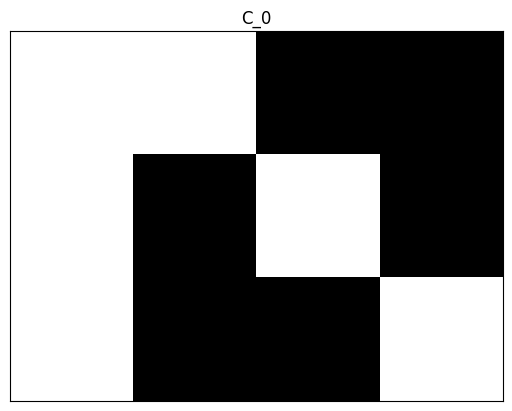

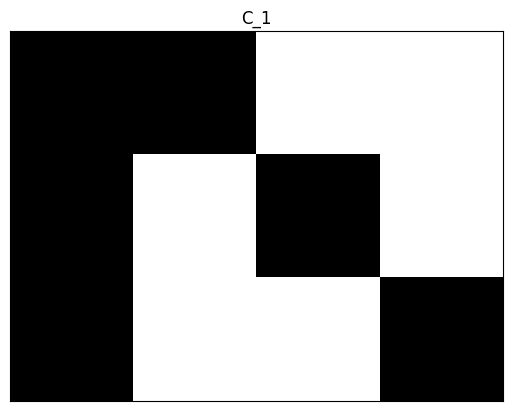

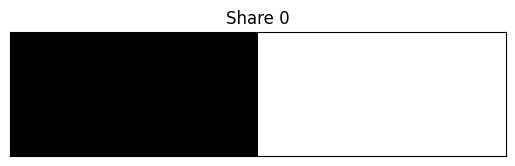

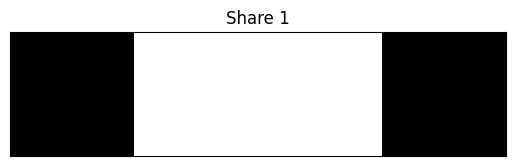

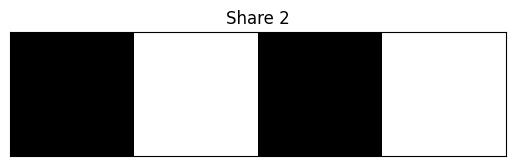

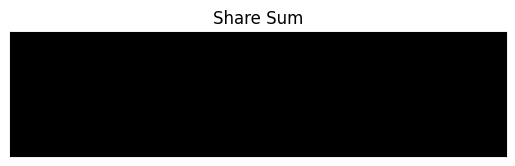

Average of share sum: 1.0
The secret should be True. (black, 1) 
Secret pixel value: True


In [15]:
SHARE_SIZE = 4
N = 3
C_1 = np.hstack((np.ones((N, 1), dtype=bool), np.eye(N, dtype=bool)))
J_0 = ~C_1

display(J_0, Label="C_0")
display(C_1, Label="C_1")

shuffle(J_0)
shuffle(C_1)

secret, shares = random_sampling_shares(J_0, C_1)
for i, share in enumerate(shares):
    display(share, Label=f"Share {i}")
share_sum = matrix_share_add(np.array(shares))
display(share_sum, Label="Share Sum")
avg = np.average(share_sum)
print(f"Average of share sum: {avg}")
if avg == 0.75:
    print("The secret should be False. (white, 0) ")
elif avg == 1.0:
    print("The secret should be True. (black, 1) ")
print (f"Secret pixel value: {secret}")
    



# General K out of K scheme
- size of shares: $2^k$ bit
- number of shares: $2^{k-1}$ subpixels

In [16]:
K = 100
def generate_kok_matrices1(K: int) -> tuple[C_Matrix, C_Matrix]:
    J_0 = np.eye(K, dtype=bool)
    J_0[-1,:] = ~J_0[-1,:]
    J_1 = np.eye(K, dtype=bool)
    return J_0, J_1


K out of K scheme 2:

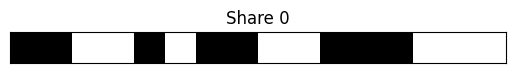

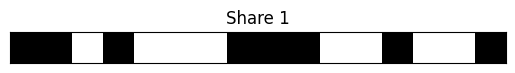

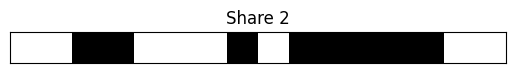

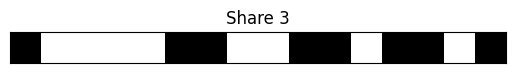

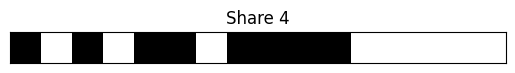

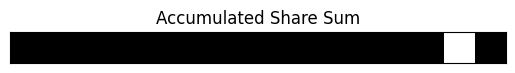

False is the secret pixel value.


In [17]:
K = 5
def powerset_even_odd(s: set) -> tuple[set, set]:
    """Generate the powerset of a given set."""
    all_subsets = set(chain.from_iterable(combinations(s, r) for r in range(len(s) + 1))) # see docs from itertools
    even_subsets = {subset for subset in all_subsets if len(subset) % 2 == 0}
    odd_subsets = all_subsets - even_subsets
    return even_subsets, odd_subsets

def generate_kok_matrices2(K: int) -> tuple[C_Matrix, C_Matrix]:
    
    S_0 = np.zeros((K,2**(K-1)), dtype=bool)
    S_1 = np.zeros((K,2**(K-1)), dtype=bool)
    
    W = set(range(K))
    PI, Sigma = powerset_even_odd(W)
    
    PI = list(PI)
    Sigma = list(Sigma)
    
    #sanity check 
    if len(PI) != 2**(K-1) or len(Sigma) != 2**(K-1):
        raise ValueError(f"Expected 2^(K-1) subsets in both PI and Sigma, got {len(PI)} and {len(Sigma)}.")
    
    
    for i in W: # e_i or each element of W
        for j in range(2**(K-1)):
            if i in PI[j]:
                S_0[i, j] = True
            if i in Sigma[j]:
                S_1[i, j] = True
    return S_0, S_1

secret, vals = random_sampling_shares(*generate_kok_matrices2(K))
for i, share in enumerate(vals):
    display(share, Label=f"Share {i}")


sum_share = functools.reduce(share_add, vals)
display(sum_share, Label="Accumulated Share Sum")
print(secret, "is the secret pixel value.")

# K out of N scheme:

In [44]:
# class HashFunction:
#     def __init__(self, coeffs: npt.NDArray, GF_SIZE: int):
#         self.coeffs = coeffs
#         self.GF_SIZE = GF_SIZE
    
#     def __call__(self, x: int) -> np.integer:
#         # evaluate the polynomial at x and take modulo GF_SIZE but i am thinking maybe K instead ? 
#         return np.polyval(self.coeffs, x) % self.GF_SIZE

def hash_family_construction(N: int, K: int, L: int|None = None) -> tuple[int, Callable, int, int]:
    # primality check 
    i=1
    while (i:= i+1)**2 <= K:
        if K % i == 0:
            raise ValueError(f"k must be a prime number, but {K} is divisible by {i}.")
    
    
    # this is derive from formula of k**l >= n
    if L is None:
        L = math.ceil(math.log(N, K))
    elif K**L < N:
        raise ValueError(f"Invalid parameters: k^l must be >= n, but got k={K}, l={L}, and n={N}. either leave l as Default or increase l.")
    GF_SIZE = K ** L
    
    # using numpy polyval(coeffs, x) to evaluate the polynomial at a given point x
    # not sure if the GF(k-1) coefficients -> [0, k-1] or [0, k^l - 1] (first seem more logical mathmatically)
    it = N**K
    coeffs = np.random.randint(0, K, size=(it,K), dtype=int)
    hash_functions = lambda coeffs_idx, x: np.polyval(coeffs[coeffs_idx], x) % GF_SIZE
    return (it, hash_functions, GF_SIZE, L)

    
def T_matrices_set(k:int, m: int, r:int) -> tuple[set[C_Matrix], set[C_Matrix]]:
    ...
    
def generate_kon_matrices(K: int, m: int, r:int , alpha: float) -> tuple[C_Matrix, C_Matrix]:
    """Generate the C_0 and C_1 matrices for the K out of K scheme."""
    ...

In [ ]:
hash_fam_size, H, *info = hash_family_construction(N=15, K=7)
test = H(0, 42)
print(f"Hash function output for input 42: {test}")
print (f"Hash family size: {hash_fam_size}, GF_SIZE: {info[0]}, L: {info[1]}")
